# Notebook 02 — SimpleMLP 784→40→20→10 on MNIST Digit Classification

**Architecture-specific analyses in §2:** pixel receptive fields, NMF stability.

**Full ablation suite in §3:** comparative sweep, causal circuit ablation, gradient attribution, cross-class circuit specificity.

**Stimulus analysis in §4:** NNLS round-trip, ID sanity check, near-OOD (Fashion-MNIST), far-OOD (4 synthetic types).

## §0 — Imports & Config

In [1]:
%matplotlib inline
import sys, os, pickle, copy, warnings
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
from scipy.integrate import trapezoid
from scipy.stats import spearmanr, wilcoxon
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_distances, paired_cosine_distances
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, TensorDataset

from src import (
    SimpleMLP,
    train_epoch, evaluate, correct,
    load_experiment, save_experiment, get_transform, get_loaders_from_config,
    collect_layer_inputs, collect_layer_inputs_generic,
    full_nmf_pipeline,
    bft,
    bft_node_vals, build_scaffold_edges, scaffold_loading_from_edges,
    scaffold_layer_sizes_from_edges,
    plot_scaffold_graph, plot_nmf_component,
    extract_tree_nodes, compute_node_activations, plot_factor_tree,
    extract_factor_fingerprint, extract_fingerprint_matrix,
    compute_stimulus_similarity, project_stimuli_onto_tree,
    extract_factor_tree_nodes, compute_factor_activations,
    nodes_at_layer, top_stimuli_factor_activations,
    assign_factors_to_classes, path_from_child, extract_importance_scores,
    magnitude_scores, act_magnitude_scores, taylor_scores,
    ablate_model, per_class_accuracy, run_ablation_sweep,
)

plt.rcParams.update({'figure.dpi': 80})
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cpu


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
MODEL_ROOT = '../data/models'
CACHE_ROOT = '../data/cache/nb02_mlp4020'
FIG_DIR    = '../figs/02_mlp_40_20_digits'
os.makedirs(MODEL_ROOT, exist_ok=True)
os.makedirs(CACHE_ROOT, exist_ok=True)
os.makedirs(FIG_DIR,    exist_ok=True)

SEED_DIRS = [os.path.join(MODEL_ROOT, f'mnist_digit_mlp_40_20_seed{s}') for s in range(5)]

# ── Model & training config ───────────────────────────────────────────────────
BASE_CONFIG = {
    'arch': 'SimpleMLP',
    'arch_kwargs': {'input_dim': 784, 'hidden_dims': [40, 20], 'output_dim': 10},
    'dataset': 'MNIST',
    'dataset_kwargs': {'root': '../data/', 'batch_size': 64},
    'label_transform': 'identity',
    'analysis_layer_indices': [2, 4, 6],
    'n_per_class': 1000,
    'input_side': 28,
}

# ── BFT hyperparameters ───────────────────────────────────────────────────────
K_MAX           = [10, 6, 10]    # NMF rank per layer (L0→L1→output)
N_BRANCHES      = [1, 2, 5]     # 5 branches at output, 2 at L1, 1 at L0
STIM_THRESHOLD  = 0.1
N_CLASSES       = 10

# ── NMF stability ─────────────────────────────────────────────────────────────
N_STAB_SEEDS    = 10
K_STAB          = [5, 5, 10]    # ranks to use for stability analysis

# ── Ablation hyperparameters ──────────────────────────────────────────────────
ABLATION_FRACS   = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
N_RANDOM_REPEATS = 10
PERCENTILES      = [50, 75, 90, 95, 99]
N_PER_CLASS      = 200    # per class for ablation layer inputs
K_TRACE          = K_MAX
K_TRACE_S3       = [5, 5, 3]   # smaller output rank for causal ablation

# ── NNLS analysis ─────────────────────────────────────────────────────────────
N_PER_CLASS_BFT  = 1000  # per class for BFT / inspection
TOP_N_FACTOR     = 50

print('Config ready')
print(f'SEED_DIRS: {SEED_DIRS}')

Config ready
SEED_DIRS: ['../data/models/mnist_digit_mlp_40_20_seed0', '../data/models/mnist_digit_mlp_40_20_seed1', '../data/models/mnist_digit_mlp_40_20_seed2', '../data/models/mnist_digit_mlp_40_20_seed3', '../data/models/mnist_digit_mlp_40_20_seed4']


## §1 — Models (5 seeds)

In [3]:
# Build shared train/test loaders from config
from src.checkpoint import MODEL_REGISTRY
_sample_cfg = dict(BASE_CONFIG)
_train_loader, _test_loader = get_loaders_from_config(_sample_cfg)
label_transform = get_transform(BASE_CONFIG['label_transform'])  # None for 'identity'

models = []
for s, seed_dir in enumerate(SEED_DIRS):
    if os.path.isdir(seed_dir) and os.path.exists(os.path.join(seed_dir, 'weights.pt')):
        m, cfg = load_experiment(seed_dir, device=DEVICE)
        m.eval()
        _, acc = evaluate(m, _test_loader, nn.CrossEntropyLoss(),
                          label_transform=label_transform, device=DEVICE)
        print(f'[seed {s}] loaded — test acc = {acc:.4f}')
    else:
        print(f'[seed {s}] not found, training …')
        torch.manual_seed(s)
        m = SimpleMLP(**BASE_CONFIG['arch_kwargs'])
        m.to(DEVICE)
        opt = torch.optim.Adam(m.parameters(), lr=3e-3)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=30)
        criterion = nn.CrossEntropyLoss()
        for epoch in range(30):
            train_epoch(m, _train_loader, opt, criterion,
                        label_transform=label_transform, device=DEVICE)
            sched.step()
        _, acc = evaluate(m, _test_loader, criterion,
                          label_transform=label_transform, device=DEVICE)
        cfg = dict(BASE_CONFIG)
        cfg['description'] = f'SimpleMLP 784->40->20->10 on MNIST digit classification, seed {s}'
        save_experiment(m, cfg, seed_dir)
        print(f'[seed {s}] trained — test acc = {acc:.4f}')
    models.append(m)

print('\nAll 5 seeds ready.')

[seed 0] loaded — test acc = 0.9525
[seed 1] loaded — test acc = 0.9517
[seed 2] loaded — test acc = 0.9498
[seed 3] loaded — test acc = 0.9525
[seed 4] loaded — test acc = 0.9565

All 5 seeds ready.


## §2 — Factorization & Inspection (seed 0)

In [4]:
model0, cfg0 = load_experiment(SEED_DIRS[0], device=DEVICE)
model0.eval()

_p = os.path.join(CACHE_ROOT, 'layer_inputs_seed0.pkl')
if os.path.exists(_p):
    with open(_p, 'rb') as f:
        _d0 = pickle.load(f)
    print('Loaded layer inputs from cache')
else:
    _d0 = collect_layer_inputs(
        model0, _test_loader.dataset,
        label_transform=label_transform,
        n_per_class=N_PER_CLASS_BFT, device=DEVICE,
    )
    with open(_p, 'wb') as f:
        pickle.dump(_d0, f)
    print('Collected and cached')

layer_inputs0 = _d0['layer_inputs']
all_targets0  = _d0['targets']
all_images0   = _d0['images']
n_samples0    = len(all_targets0)
layer_names   = {0: 'L0 (784→40)', 1: 'L1 (40→20)', 2: 'Out (20→10)'}
print(f'{n_samples0} samples | layers: {[x.shape for x in layer_inputs0]}')

Loaded layer inputs from cache
9323 samples | layers: [(9323, 784), (9323, 40), (9323, 20)]


In [5]:
# ── BFT (seed 0) ──────────────────────────────────────────────────────────────
tree_root0 = bft(
    model0, layer_inputs0,
    k_max=K_MAX, n_branches=N_BRANCHES,
    stimulus_threshold=STIM_THRESHOLD,
    weighting='img_selectivity', verbose=1, n_jobs=3,
)


tree_nodes0   = extract_tree_nodes(tree_root0)
factor_nodes0 = extract_factor_tree_nodes(tree_root0)
l0_nodes0     = nodes_at_layer(tree_root0, 0)
print(f'Tree nodes: {len(tree_nodes0)}  factor nodes: {len(factor_nodes0)}')
print(f'Root factors: K={len(tree_root0["lambdas"])}')

[BFT] Layer 3/3 '2' (fc)  path=[]


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L3 '2' (fc)]   K=10  t=2.175s
[BFT] Layer 2/3 '1' (fc)  path=[0]
[BFT L2 '1' (fc)]   K=6  t=0.236s
[BFT] Layer 1/3 '0' (fc)  path=[0, 0]
[BFT L1 '0' (fc)]   K=10  t=14.332s
[BFT] Layer 1/3 '0' (fc)  path=[0, 1]
[BFT L1 '0' (fc)]   K=10  t=11.735s
[BFT] Layer 2/3 '1' (fc)  path=[1]
[BFT L2 '1' (fc)]   K=6  t=0.168s
[BFT] Layer 1/3 '0' (fc)  path=[1, 0]


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L1 '0' (fc)]   K=10  t=226.500s
[BFT] Layer 1/3 '0' (fc)  path=[1, 1]
[BFT L1 '0' (fc)]   K=10  t=9.222s
[BFT] Layer 2/3 '1' (fc)  path=[2]
[BFT L2 '1' (fc)]   K=6  t=0.183s
[BFT] Layer 1/3 '0' (fc)  path=[2, 0]
[BFT L1 '0' (fc)]   K=10  t=9.550s
[BFT] Layer 1/3 '0' (fc)  path=[2, 1]
[BFT L1 '0' (fc)]   K=10  t=9.284s
[BFT] Layer 2/3 '1' (fc)  path=[3]
[BFT L2 '1' (fc)]   K=6  t=0.174s
[BFT] Layer 1/3 '0' (fc)  path=[3, 0]


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L1 '0' (fc)]   K=10  t=243.677s
[BFT] Layer 1/3 '0' (fc)  path=[3, 1]
[BFT L1 '0' (fc)]   K=10  t=11.833s
[BFT] Layer 2/3 '1' (fc)  path=[4]
[BFT L2 '1' (fc)]   K=6  t=0.224s
[BFT] Layer 1/3 '0' (fc)  path=[4, 0]
[BFT L1 '0' (fc)]   K=10  t=11.734s
[BFT] Layer 1/3 '0' (fc)  path=[4, 1]


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L1 '0' (fc)]   K=10  t=285.705s
Tree nodes: 16  factor nodes: 140
Root factors: K=10


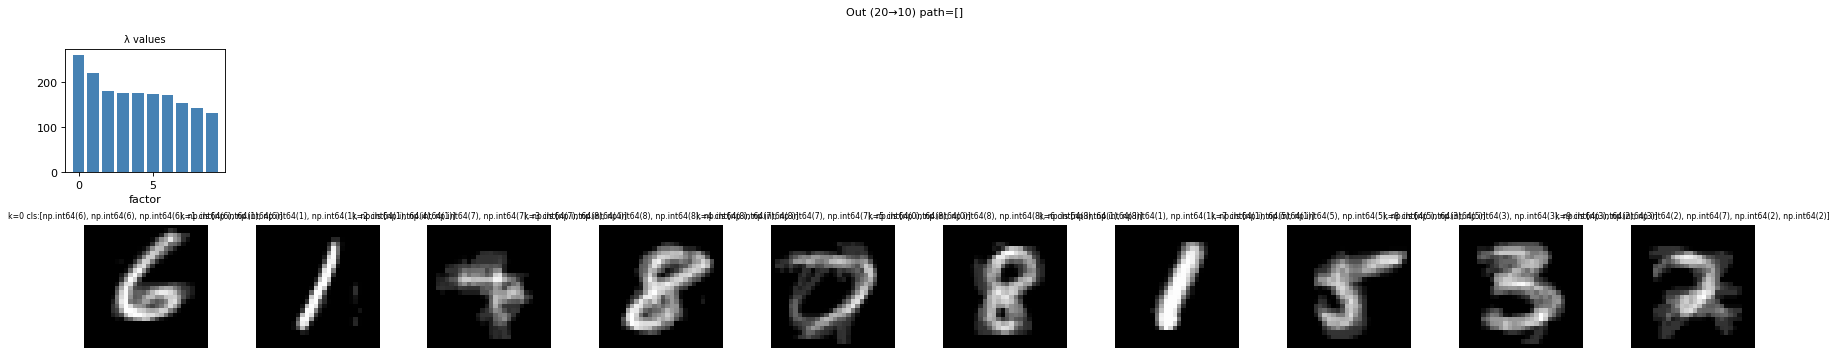

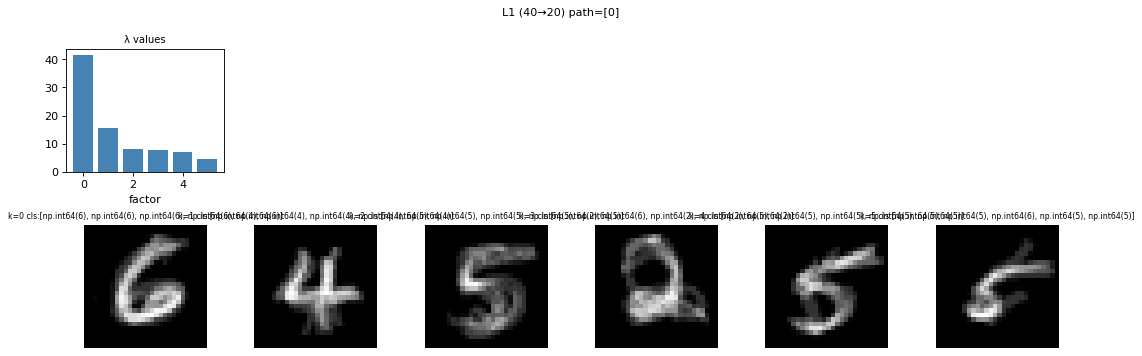

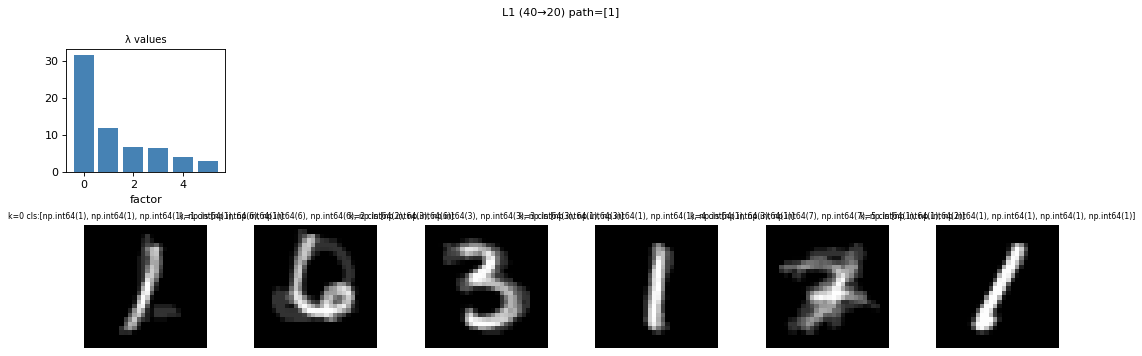

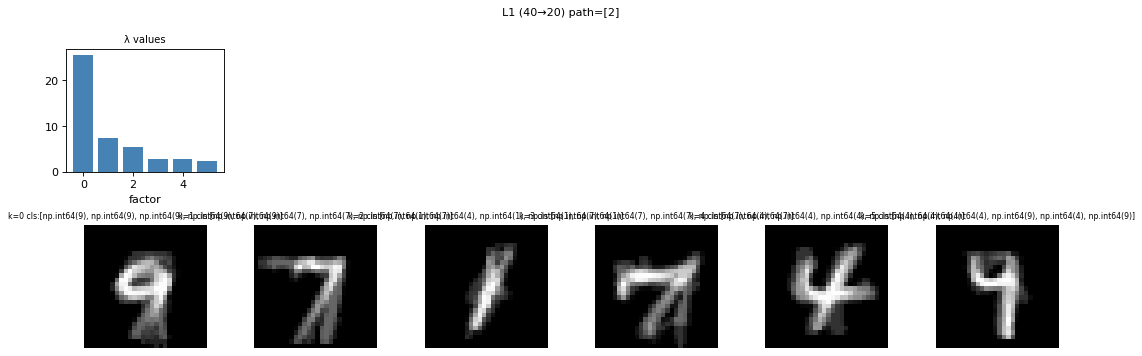

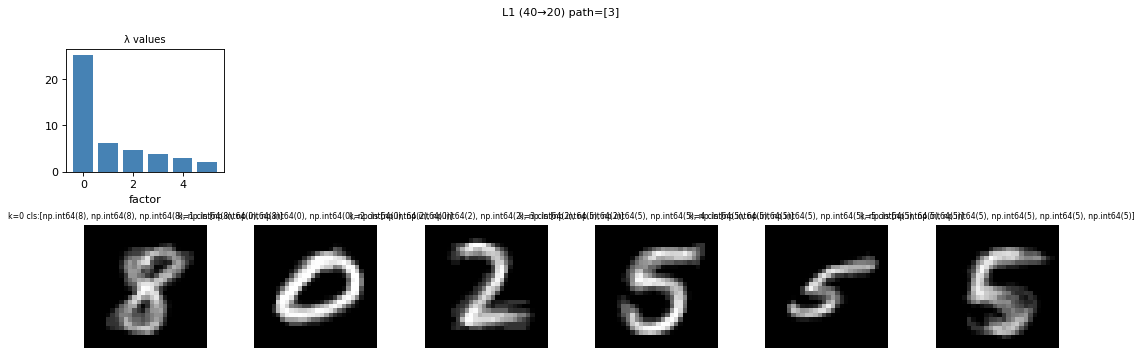

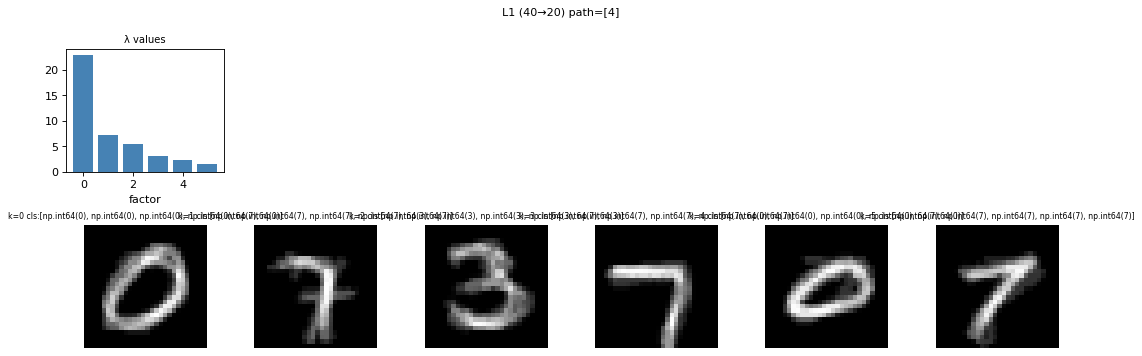

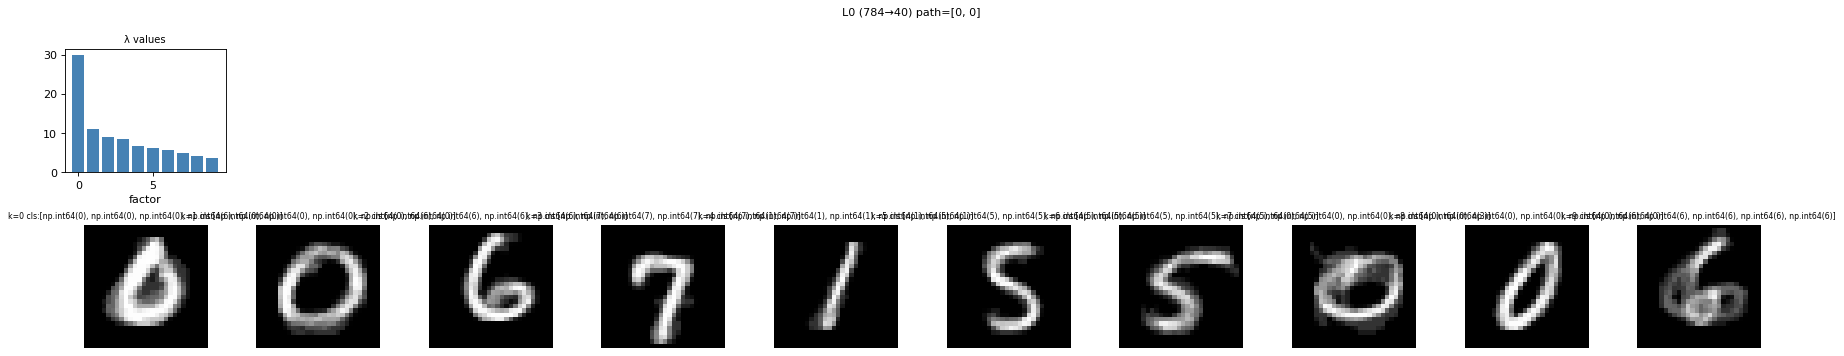

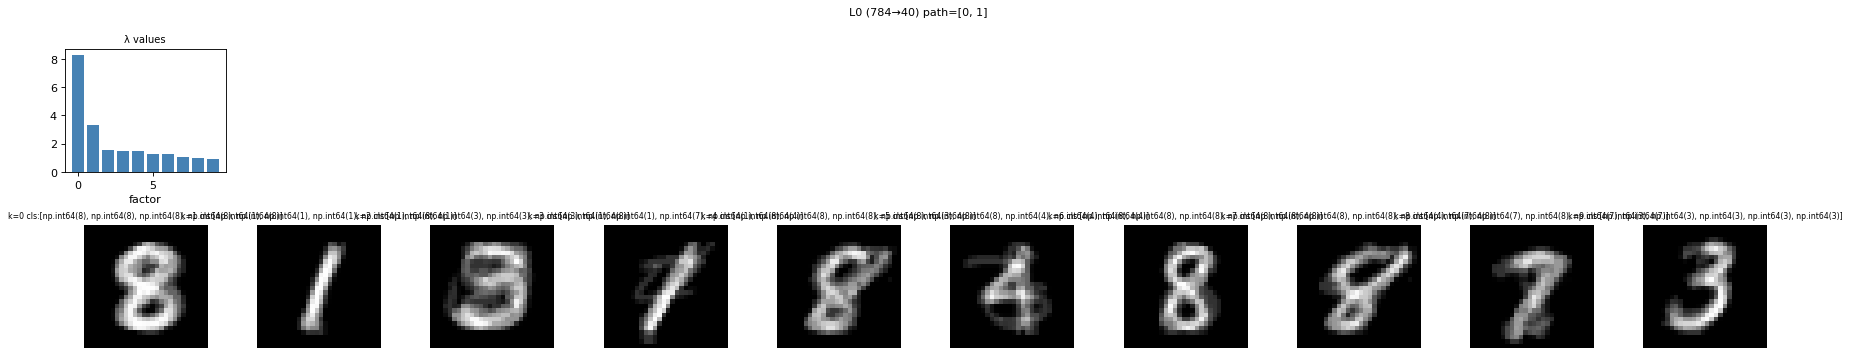

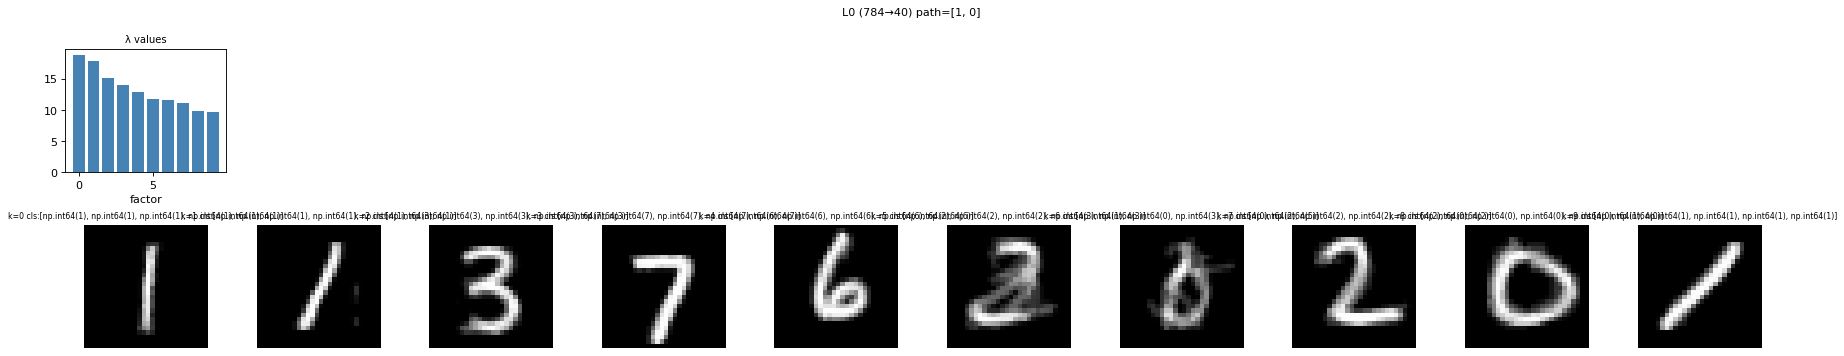

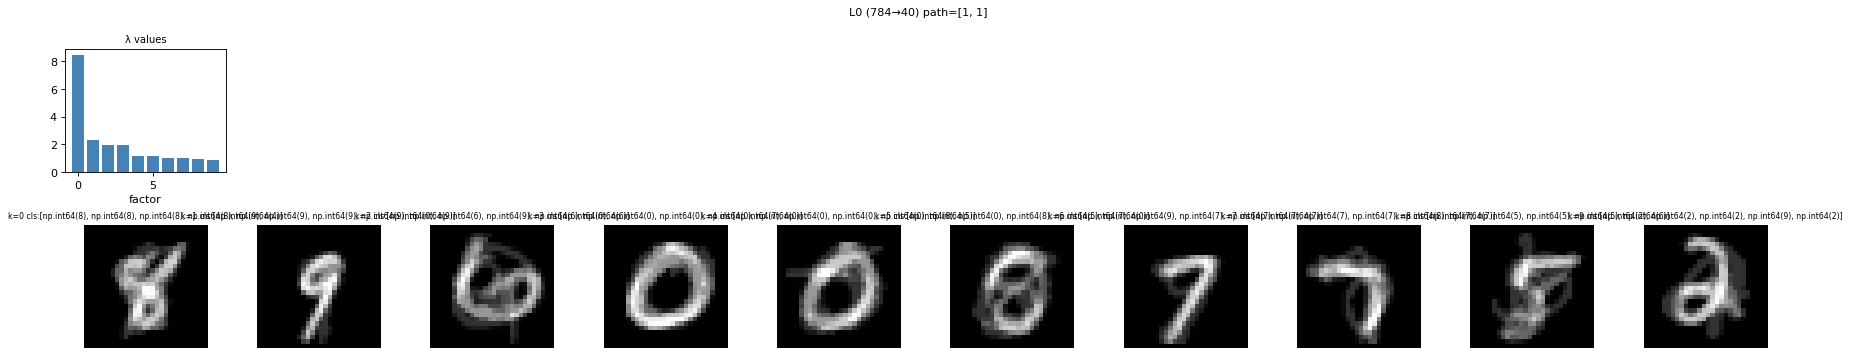

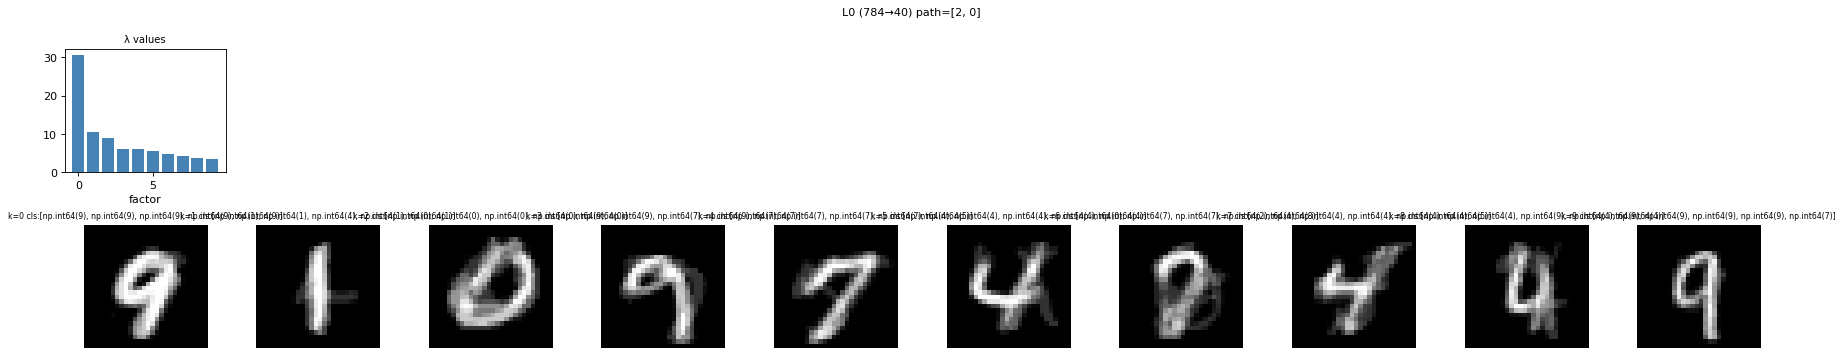

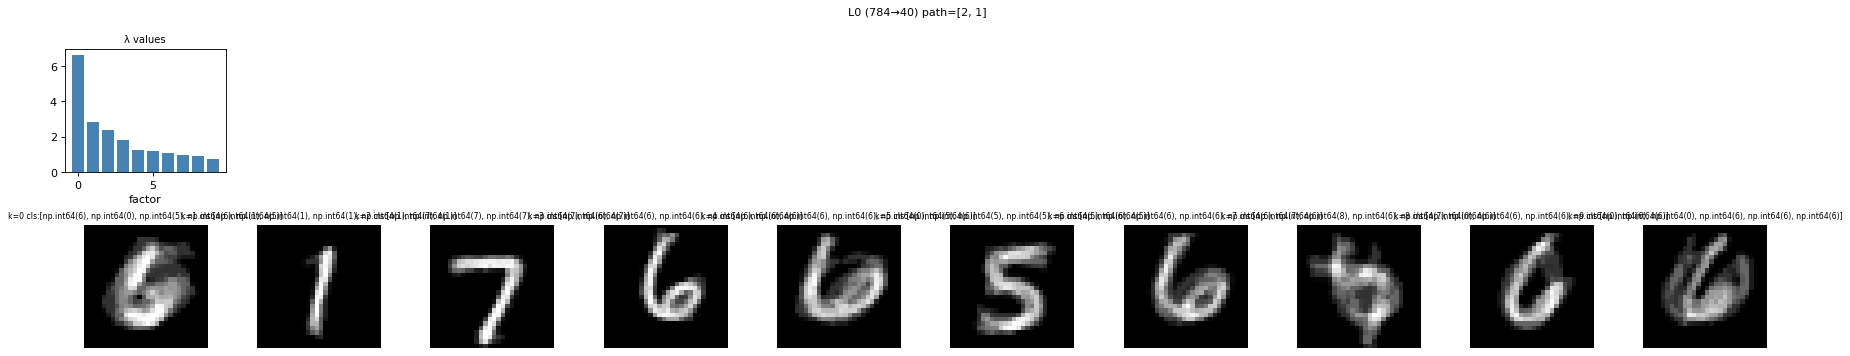

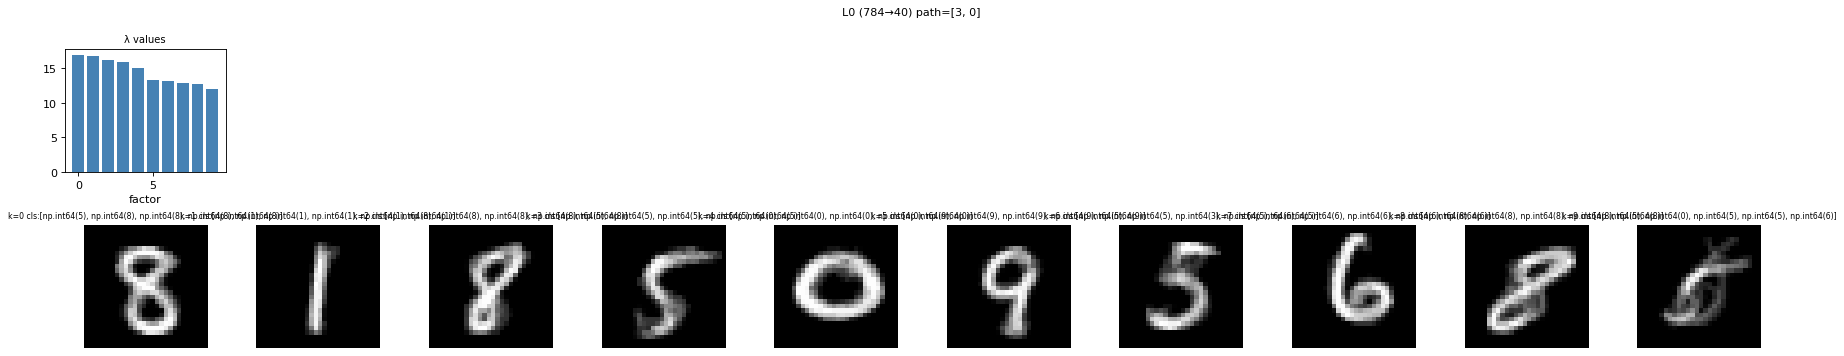

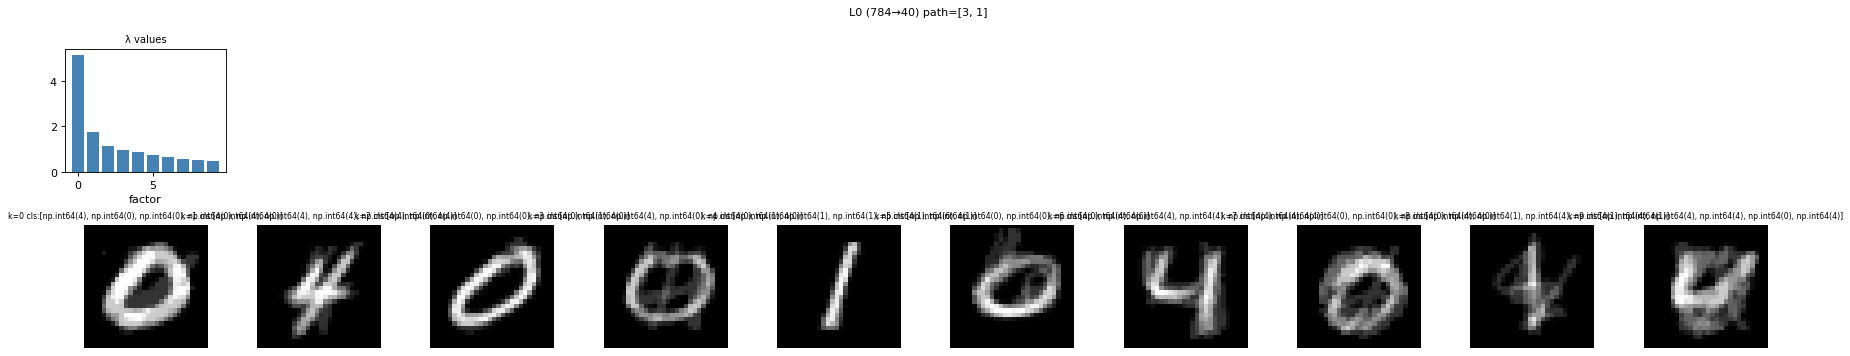

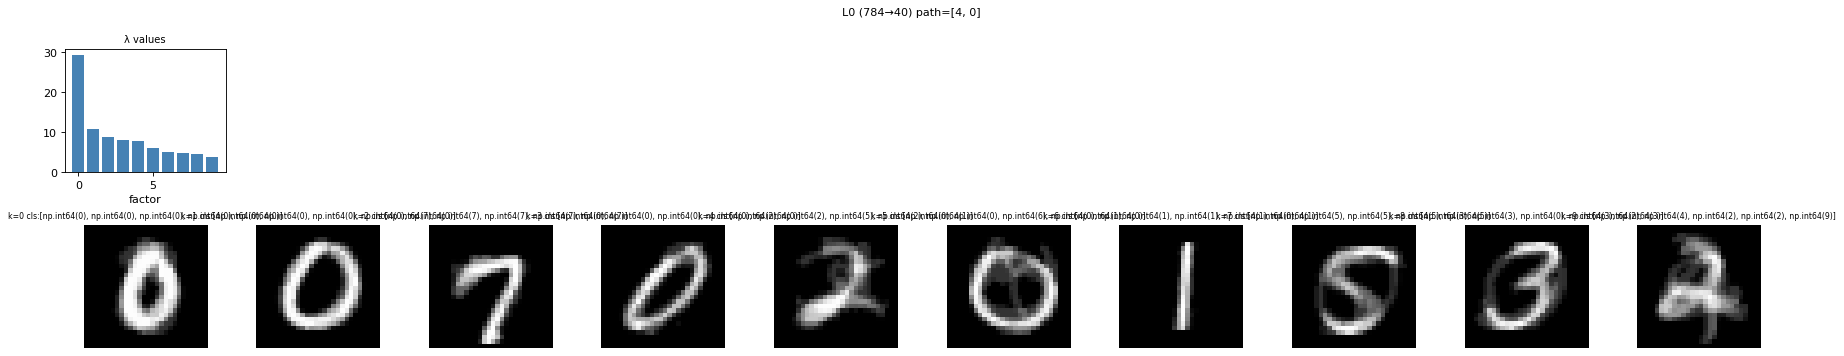

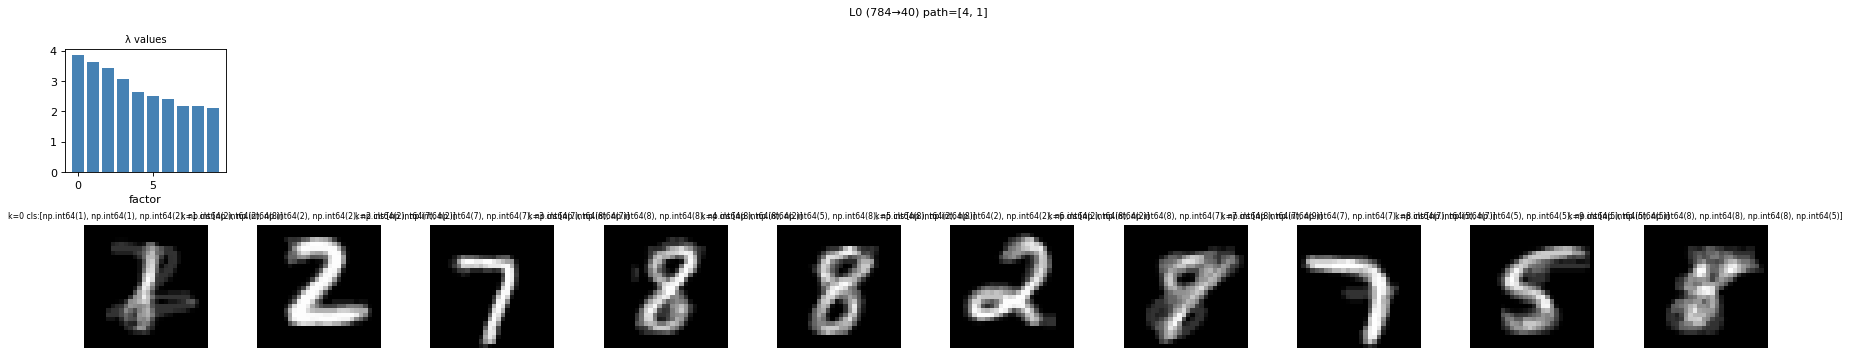

In [6]:
# ── Per-layer factor panels: lambdas + top-stimulus grid ──────────────────────
CLASS_NAMES = {i: str(i) for i in range(N_CLASSES)}

for node in tree_nodes0:
    K = len(node['lambdas'])
    fig, axes = plt.subplots(2, K, figsize=(max(K * 2.2, 8), 4.5))
    if K == 1:
        axes = axes.reshape(2, 1)

    # Row 0: lambda bar + class distribution
    axes[0, 0].bar(range(K), node['lambdas'], color='steelblue')
    axes[0, 0].set_title('λ values', fontsize=9)
    axes[0, 0].set_xlabel('factor')
    for kk in range(1, K):
        axes[0, kk].axis('off')

    # Row 1: top stimuli per factor (avg image)
    for k in range(K):
        scores = node['img_factors'][:, k]
        top_idx = np.argsort(scores)[::-1][:5]
        avg_img = all_images0[top_idx].mean(axis=0).squeeze()
        class_labels = all_targets0[top_idx]
        axes[1, k].imshow(avg_img, cmap='gray', vmin=0, vmax=1)
        axes[1, k].set_title(f'k={k} cls:{list(class_labels)}', fontsize=7)
        axes[1, k].axis('off')

    lname = layer_names.get(node['layer_idx'], f'layer{node["layer_idx"]}')
    fig.suptitle(f'{lname} path={node["path"]}', fontsize=10)
    plt.tight_layout()
    path_str = '_'.join(map(str, node['path'])) if node['path'] else 'root'
    plt.savefig(os.path.join(FIG_DIR, f'factors_{lname.split(" ")[0]}_{path_str}.pdf'),
                bbox_inches='tight')
    plt.show()

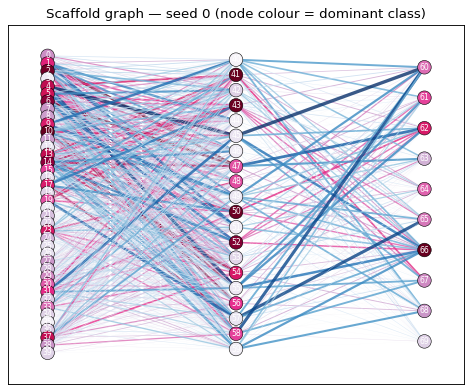

In [7]:
# ── Scaffold graph (seed 0) ───────────────────────────────────────────────────
def _get_spine(root):
    chain, node = [root], root
    while node['children']:
        node = node['children'][0]; chain.append(node)
    return chain

spine = _get_spine(tree_root0)
layer_results = list(reversed(spine))          # forward order: input → output
edge_matrices, neg_edge_matrices = build_scaffold_edges(
    layer_results[1:], fi='path', fi_seed=layer_results[0], top_pct=0.05,
)
scaffold_loading = scaffold_loading_from_edges(edge_matrices)
layer_sizes = scaffold_layer_sizes_from_edges(edge_matrices)
fig = plot_scaffold_graph(scaffold_loading, edge_matrices, layer_sizes,
                          neg_edge_matrices=neg_edge_matrices)
fig.axes[0].set_title('Scaffold graph — seed 0 (node colour = dominant class)', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'scaffold_seed0.pdf'), bbox_inches='tight')
plt.show()

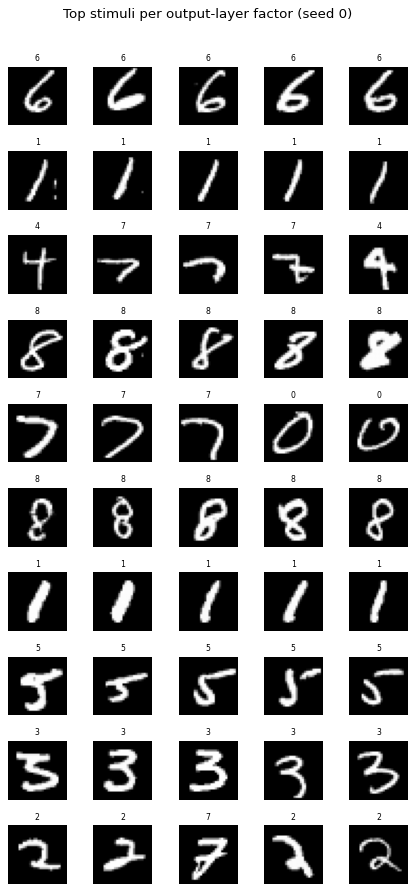

In [8]:
# ── Top-N stimulus gallery per output factor ──────────────────────────────────
K_root = len(tree_root0['lambdas'])
fig, axes = plt.subplots(K_root, TOP_N_FACTOR // 10, figsize=(TOP_N_FACTOR // 10 * 1.1, K_root * 1.1))
if K_root == 1:
    axes = axes.reshape(1, -1)

for k in range(K_root):
    scores = tree_root0['img_factors'][:, k]
    top_idx = np.argsort(scores)[::-1][:TOP_N_FACTOR // 10]
    for col, idx in enumerate(top_idx):
        axes[k, col].imshow(all_images0[idx].squeeze(), cmap='gray', vmin=0, vmax=1)
        axes[k, col].set_title(str(int(all_targets0[idx])), fontsize=7)
        axes[k, col].axis('off')
    axes[k, 0].set_ylabel(f'Out k={k}\nλ={tree_root0["lambdas"][k]:.2f}',
                           fontsize=8, rotation=0, labelpad=50, va='center')

plt.suptitle('Top stimuli per output-layer factor (seed 0)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'top_stimuli_output_layer.pdf'), bbox_inches='tight')
plt.show()

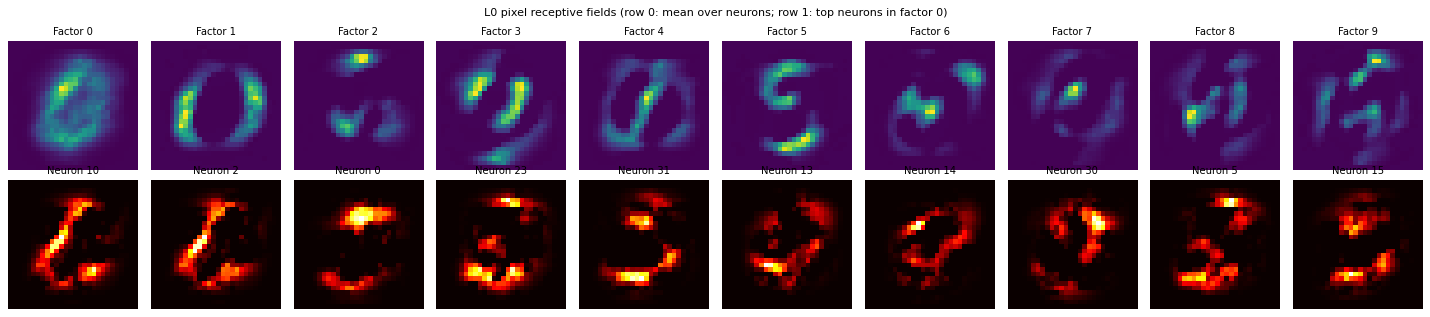

In [9]:
# ── Pixel receptive fields: L0 neural factors reshaped to (n_neurons, 28, 28) ─
# For SimpleMLP, L0 connects 784 inputs to 40 neurons.
# neural_factors shape at L0: (40 * 784, K)  →  reshape each column to (40, 784)

l0_node = l0_nodes0[0]   # first leaf node
nf_l0   = l0_node['neural_factors']   # (40*784, K)
K_l0    = nf_l0.shape[1]
nf_l0_r = nf_l0.reshape(40, 784, K_l0)  # (n_neurons, n_inputs, K)

# Per-factor: mean over neurons → pixel map
fig, axes = plt.subplots(2, K_l0, figsize=(K_l0 * 1.8, 4))
if K_l0 == 1:
    axes = axes.reshape(2, 1)
for k in range(K_l0):
    pix = nf_l0_r[:, :, k].mean(axis=0).reshape(28, 28)
    axes[0, k].imshow(pix, cmap='viridis')
    axes[0, k].set_title(f'Factor {k}', fontsize=9)
    axes[0, k].axis('off')

# Per-neuron: top-5 neurons in factor 0
top_neurons = np.argsort(nf_l0_r[:, :, 0].sum(axis=1))[::-1][:K_l0]
for col, ni in enumerate(top_neurons):
    pix = nf_l0_r[ni, :, 0].reshape(28, 28)
    axes[1, col].imshow(pix, cmap='hot')
    axes[1, col].set_title(f'Neuron {ni}', fontsize=9)
    axes[1, col].axis('off')

plt.suptitle('L0 pixel receptive fields (row 0: mean over neurons; row 1: top neurons in factor 0)',
             fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pixel_receptive_fields_l0.pdf'), bbox_inches='tight')
plt.show()

In [10]:
# ── NMF Stability Analysis (10 random seeds × 3 layers) ──────────────────────
# Uses joint_arbor matrices from the seed-0 BFT single-chain trace.

def factor_cosine_sim(W1, W2):
    W1 = W1 / (np.linalg.norm(W1, axis=0, keepdims=True) + 1e-12)
    W2 = W2 / (np.linalg.norm(W2, axis=0, keepdims=True) + 1e-12)
    return W1.T @ W2

def best_match_sim(W1, W2):
    sim = factor_cosine_sim(W1, W2)
    r, c = linear_sum_assignment(-sim)
    return float(sim[r, c].mean())

_p_stab = os.path.join(CACHE_ROOT, 'stability.pkl')
if os.path.exists(_p_stab):
    with open(_p_stab, 'rb') as f:
        stab = pickle.load(f)
    print('Loaded stability data from cache')
else:
    # Get joint_arbors from a single-branch BFT trace
    _p_spine = os.path.join(CACHE_ROOT, 'bft_seed0_spine.pkl')
    if os.path.exists(_p_spine):
        with open(_p_spine, 'rb') as f:
            trace0 = pickle.load(f)
    else:
        _root_sp = bft(model0, layer_inputs0, k_max=K_STAB, n_branches=1,
                       stimulus_threshold=STIM_THRESHOLD, n_jobs=3)
        def _spine(root):
            chain, node = [root], root
            while node['children']:
                node = node['children'][0]; chain.append(node)
            return chain
        trace0 = _spine(_root_sp)
        with open(_p_spine, 'wb') as f:
            pickle.dump(trace0, f)

    joint_arbors = {res['layer_idx']: res['joint_arbor'] for res in trace0}
    print(f'Joint arbors: {[(l, ja.shape) for l, ja in sorted(joint_arbors.items())]}')

    print(f'Computing NMF stability ({N_STAB_SEEDS} seeds × 3 layers) …')
    K_per = {0: K_STAB[0], 1: K_STAB[1], 2: K_STAB[2]}
    stab = {}
    for l_idx, ja in sorted(joint_arbors.items()):
        K = K_per[l_idx]
        print(f'  Layer {l_idx} (K={K})…')
        factors = []
        for seed in range(N_STAB_SEEDS):
            img_f, neu_f, lams = full_nmf_pipeline(ja, K, random_state=seed,
                                                    max_iter=5000, init='random')
            factors.append({'img': img_f, 'neu': neu_f})
        n = N_STAB_SEEDS
        sim_img = np.zeros((n, n)); sim_neu = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                sim_img[i, j] = best_match_sim(factors[i]['img'], factors[j]['img'])
                sim_neu[i, j] = best_match_sim(factors[i]['neu'], factors[j]['neu'])
        stab[l_idx] = {'sim_img': sim_img, 'sim_neu': sim_neu}
        offdiag = sim_img[~np.eye(n, dtype=bool)]
        print(f'  img off-diag mean: {offdiag.mean():.3f}')
    with open(_p_stab, 'wb') as f:
        pickle.dump(stab, f)
    print('Saved.')

# ── Plot stability heatmaps ───────────────────────────────────────────────────
mask_offdiag = ~np.eye(N_STAB_SEEDS, dtype=bool)
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for col, l_idx in enumerate(sorted(stab)):
    for row, (key, label) in enumerate([('sim_img', 'Stimulus factors'),
                                         ('sim_neu', 'Neural factors')]):
        ax = axes[row, col]
        sns.heatmap(stab[l_idx][key], ax=ax, vmin=0, vmax=1, cmap='Blues',
                    annot=False, cbar=(col == 2))
        ax.set_title(f'{label}\n{layer_names[l_idx]}', fontsize=10)
        if col == 0: ax.set_ylabel('NMF seed')
        if row == 1: ax.set_xlabel('NMF seed')
plt.suptitle('Pairwise Hungarian-matched cosine similarity (10 NMF seeds)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'stability_heatmaps.pdf'), bbox_inches='tight')
plt.show()

# Boxplot summary
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax_i, (key, label) in enumerate([('sim_img', 'Stimulus'), ('sim_neu', 'Neural')]):
    ax = axes[ax_i]
    data_bp, tick_labels = [], []
    for l_idx in sorted(stab):
        vals = stab[l_idx][key][mask_offdiag]
        data_bp.append(vals)
        tick_labels.append(layer_names[l_idx])
        stat, pval = wilcoxon(vals - 0.90, alternative='greater')
        print(f'{layer_names[l_idx]} {label}: {vals.mean():.3f}±{vals.std():.3f}  '
              f'Wilcoxon vs 0.90 p={pval:.4f}')
    bp = ax.boxplot(data_bp, labels=tick_labels, patch_artist=True)
    for patch, c in zip(bp['boxes'], ['#4e9a9e', '#e08550', '#6b66aa']):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(0.90, color='red', linestyle='--', label='0.90 threshold')
    ax.set_ylim(0, 1.05); ax.set_ylabel('Cosine similarity')
    ax.set_title(f'Stability: {label} factors (off-diagonal)')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'stability_boxplots.pdf'), bbox_inches='tight')
plt.show()

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


OSError: [Errno 28] No space left on device

## §3 — Ablation (all 5 seeds)

In [ ]:
# ── §3.1: Comparative ablation sweep ─────────────────────────────────────────
METHODS = ['algo_top', 'algo_bottom', 'magnitude', 'act_magnitude', 'taylor', 'random']
METHOD_STYLES = {
    'algo_top':      dict(color='red',      lw=2.0, ls='-',  label='algo (most important)'),
    'algo_bottom':   dict(color='orange',   lw=1.5, ls='--', label='algo (least important)'),
    'magnitude':     dict(color='gray',     lw=1.5, ls='-',  label='magnitude'),
    'act_magnitude': dict(color='steelblue',lw=1.5, ls='--', label='act × magnitude'),
    'taylor':        dict(color='green',    lw=1.5, ls='-',  label='Taylor'),
    'random':        dict(color='black',    lw=1.0, ls=':',  label='random'),
}

all_results = []
for s, exp_dir in enumerate(SEED_DIRS):
    cache_path = os.path.join(CACHE_ROOT, f'ablation_seed{s}.pkl')
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            all_results.append(pickle.load(f))
        print(f'[seed {s}] loaded ablation from cache')
        continue

    print(f'\n=== seed {s} ===')
    model_s, cfg_s = load_experiment(exp_dir, device=DEVICE)
    _, test_loader_s = get_loaders_from_config(cfg_s)

    data_s = collect_layer_inputs(
        model_s, test_loader_s.dataset,
        label_transform=label_transform, n_per_class=None, device=DEVICE,
    )
    li_s = data_s['layer_inputs']; tgt_s = data_s['targets']

    root_s = bft(model_s, li_s, k_max=K_TRACE, n_branches=N_BRANCHES,
                  stimulus_threshold=STIM_THRESHOLD, n_jobs=3)
    class_to_child = assign_factors_to_classes(root_s, tgt_s, N_CLASSES)
    algo_scores = {d: extract_importance_scores(path_from_child(root_s, class_to_child[d]))
                   for d in range(N_CLASSES)}
    mag_sc  = magnitude_scores(model_s)
    amag_sc = act_magnitude_scores(model_s, li_s)

    seed_results = {m: {} for m in METHODS}
    for d in range(N_CLASSES):
        print(f'  class {d}', end=' ', flush=True)
        tay_sc = taylor_scores(model_s, test_loader_s, label_transform, DEVICE, d)
        score_map = {
            'algo_top':      algo_scores[d], 'algo_bottom': algo_scores[d],
            'magnitude':     mag_sc,         'act_magnitude': amag_sc,
            'taylor':        tay_sc,          'random':        mag_sc,
        }
        for method in METHODS:
            seed_results[method][d] = run_ablation_sweep(
                model_s, score_map[method], ABLATION_FRACS,
                test_loader_s, label_transform, DEVICE,
                method=method, n_random_repeats=N_RANDOM_REPEATS,
            )
        print('done')

    with open(cache_path, 'wb') as f:
        pickle.dump(seed_results, f)
    all_results.append(seed_results)

valid = [r for r in all_results if r is not None]
print(f'\n{len(valid)} seeds loaded.')

In [ ]:
# ── Per-class accuracy vs ablation fraction ───────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5), sharey=True)
axes = axes.flatten()
for d in range(N_CLASSES):
    ax = axes[d]
    for method in METHODS:
        accs = np.array([[r[method][d][f][d] for f in ABLATION_FRACS] for r in valid])
        mu, std = accs.mean(0), accs.std(0)
        st = METHOD_STYLES[method]
        ax.plot(ABLATION_FRACS, mu, color=st['color'], lw=st['lw'], ls=st['ls'], label=st['label'])
        ax.fill_between(ABLATION_FRACS, mu - std, mu + std, color=st['color'], alpha=0.12)
    ax.set_title(f'digit {d}'); ax.set_xlabel('fraction ablated')
    if d % 5 == 0: ax.set_ylabel('accuracy')
    ax.set_ylim(0, 1.05)
axes[-1].legend(loc='lower left', fontsize=8)
fig.suptitle('Per-class accuracy after ablating top-f fraction of weights', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ablation_per_class.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── AUC summary ───────────────────────────────────────────────────────────────
fracs = np.array(ABLATION_FRACS)
auc_table = {}
for method in METHODS:
    per_class_auc = [np.mean([trapezoid([r[method][d][f][d] for f in ABLATION_FRACS], fracs)
                              for r in valid]) for d in range(N_CLASSES)]
    auc_table[method] = np.array(per_class_auc)

fig, ax = plt.subplots(figsize=(9, 3.5))
x = np.arange(N_CLASSES); width = 0.12
for k, method in enumerate(METHODS):
    st = METHOD_STYLES[method]
    ax.bar(x + k * width, auc_table[method], width, color=st['color'], label=st['label'], alpha=0.8)
ax.set_xticks(x + width * (len(METHODS) - 1) / 2)
ax.set_xticklabels([f'digit {d}' for d in range(N_CLASSES)])
ax.set_ylabel('AUC (lower = steeper drop)'); ax.set_title('AUC summary')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ablation_auc.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Cross-class side effects ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(METHODS), figsize=(13, 3.5), sharey=True)
for ax, method in zip(axes, METHODS):
    mean_side = [np.mean([np.mean([r[method][d][f][c] for c in range(N_CLASSES) if c != d
                                   for f in ABLATION_FRACS]) for r in valid])
                 for d in range(N_CLASSES)]
    ax.bar(range(N_CLASSES), mean_side, color=METHOD_STYLES[method]['color'], alpha=0.8)
    ax.set_title(METHOD_STYLES[method]['label'], fontsize=9)
    ax.set_xlabel('ablated class'); ax.set_ylim(0, 1.05)
    if ax is axes[0]: ax.set_ylabel('mean acc on bystanders')
fig.suptitle('Bystander-class accuracy (higher = less collateral damage)', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ablation_bystander.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Statistical tests A–E ─────────────────────────────────────────────────────
def target_aucs(method):
    return np.array([[trapezoid([r[method][d][f][d] for f in ABLATION_FRACS], fracs)
                      for d in range(N_CLASSES)] for r in valid])

def within_run_aucs(method):
    at = np.zeros((len(valid), N_CLASSES))
    ao = np.zeros((len(valid), N_CLASSES))
    for si, r in enumerate(valid):
        for d in range(N_CLASSES):
            at[si, d] = trapezoid([r[method][d][f][d] for f in ABLATION_FRACS], fracs)
            ao[si, d] = np.mean([trapezoid([r[method][d][f][c] for f in ABLATION_FRACS], fracs)
                                  for c in range(N_CLASSES) if c != d])
    return at, ao

def _wilcoxon(a, b, alt='greater'):
    diff = a - b
    if np.all(diff == 0): return np.nan, 1.0
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return wilcoxon(diff, alternative=alt)

a_top = target_aucs('algo_top'); a_bot = target_aucs('algo_bottom')

print('=== TEST A: algo_top degrades target faster than baselines ===')
for bm in ['taylor', 'random']:
    b = target_aucs(bm)
    _, p = _wilcoxon(b.ravel(), a_top.ravel(), 'greater')
    sign = '*' if p < 0.05 else ('+' if p < 0.10 else ' ')
    print(f'  vs {bm:<10}  algo_top={a_top.mean():.4f}  {bm}={b.mean():.4f}  p={p:.4f} {sign}')

print('\n=== TEST B: algo_top — target drops faster than bystanders ===')
at_top, ao_top = within_run_aucs('algo_top')
_, p_B = _wilcoxon(ao_top.ravel(), at_top.ravel(), 'greater')
sign = '*' if p_B < 0.05 else ('+' if p_B < 0.10 else ' ')
print(f'  AUC_target={at_top.mean():.4f}  AUC_others={ao_top.mean():.4f}  '
      f'delta={( ao_top - at_top).mean():+.4f}  p={p_B:.4f} {sign}')

print('\n=== TEST C: algo_bottom protects target vs baselines ===')
for bm in ['magnitude', 'act_magnitude', 'taylor', 'random']:
    b = target_aucs(bm)
    _, p = _wilcoxon(a_bot.ravel(), b.ravel(), 'greater')
    sign = '*' if p < 0.05 else ('+' if p < 0.10 else ' ')
    print(f'  vs {bm:<16}  algo_bottom={a_bot.mean():.4f}  {bm}={b.mean():.4f}  p={p:.4f} {sign}')

print('\n=== TEST D: algo_bottom — target drops slower than bystanders ===')
at_bot, ao_bot = within_run_aucs('algo_bottom')
_, p_D = _wilcoxon(at_bot.ravel(), ao_bot.ravel(), 'greater')
sign = '*' if p_D < 0.05 else ('+' if p_D < 0.10 else ' ')
print(f'  AUC_target={at_bot.mean():.4f}  AUC_others={ao_bot.mean():.4f}  '
      f'delta={( at_bot - ao_bot).mean():+.4f}  p={p_D:.4f} {sign}')

print('\n=== TEST E: direct ranking — most-important > least-important damage ===')
_, p = _wilcoxon(a_bot.ravel(), a_top.ravel(), 'greater')
sign = '*' if p < 0.05 else ('+' if p < 0.10 else ' ')
print(f'  algo_top={a_top.mean():.4f}  algo_bottom={a_bot.mean():.4f}  '
      f'delta={( a_bot - a_top).mean():+.4f}  p={p:.4f} {sign}')

In [ ]:
# ── §3.2: Causal Circuit Ablation ────────────────────────────────────────────
def circuit_keys_at_pct(scores, pct):
    thr = np.percentile(list(scores.values()), pct)
    return [k for k, v in scores.items() if v >= thr]

def _spine(root):
    chain, node = [root], root
    while node['children']:
        node = node['children'][0]; chain.append(node)
    return chain

causal = {}
for s, seed_dir in enumerate(SEED_DIRS):
    _p = os.path.join(CACHE_ROOT, f'causal_seed{s}.pkl')
    if os.path.exists(_p):
        with open(_p, 'rb') as f:
            causal[s] = pickle.load(f)
        print(f'Seed {s}: loaded from cache')
        continue

    print(f'Seed {s}: computing ...')
    model_s, cfg_s = load_experiment(seed_dir, device=DEVICE)
    model_s.eval()
    data_s = collect_layer_inputs(model_s, _test_loader.dataset, label_transform=label_transform,
                                   n_per_class=N_PER_CLASS, device=DEVICE)
    li_s = data_s['layer_inputs']; tgt_s = data_s['targets']
    test_loader_causal = DataLoader(_test_loader.dataset, batch_size=256)
    base_accs = per_class_accuracy(model_s, test_loader_causal, label_transform, DEVICE)

    causal[s] = {}
    for d in range(N_CLASSES):
        mask_d = (tgt_s == d)
        li_d   = [x[mask_d] for x in li_s]
        root_d = bft(model_s, li_d, k_max=K_TRACE_S3, n_branches=1,
                     stimulus_threshold=STIM_THRESHOLD, n_jobs=3)
        scores_d = extract_importance_scores(_spine(root_d))

        all_accs = {}; fracs_c = {}
        for pct in PERCENTILES:
            keys = circuit_keys_at_pct(scores_d, pct)
            abl  = ablate_model(model_s, keys)
            all_accs[pct] = per_class_accuracy(abl, test_loader_causal, label_transform, DEVICE)
            total_w = sum(model_s.layers[li].weight.numel()
                          for li in model_s.linear_layer_indices())
            fracs_c[pct] = len(keys) / total_w

        causal[s][d] = {'baseline_accs': base_accs, 'all_class_accs': all_accs,
                         'circuit_fracs': fracs_c}
        print(f'  digit {d}: target drop@90={base_accs[d] - all_accs[90][d]:.3f}')

    with open(_p, 'wb') as f:
        pickle.dump(causal[s], f)
    print(f'  Saved seed {s}.')

print('Causal ablation complete.')

In [ ]:
# ── Causal ablation plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
axes_flat = axes.flatten()
n_seeds_c = len(causal)

for d in range(N_CLASSES):
    ax = axes_flat[d]
    tgt_m, bys_m, tgt_s_arr, bys_s_arr = [], [], [], []
    for pct in PERCENTILES:
        t_vals = [causal[s][d]['baseline_accs'][d] - causal[s][d]['all_class_accs'][pct][d]
                  for s in range(n_seeds_c)]
        b_vals = [np.mean([causal[s][d]['baseline_accs'][c] - causal[s][d]['all_class_accs'][pct][c]
                            for c in range(N_CLASSES) if c != d]) for s in range(n_seeds_c)]
        tgt_m.append(np.mean(t_vals)); tgt_s_arr.append(np.std(t_vals))
        bys_m.append(np.mean(b_vals)); bys_s_arr.append(np.std(b_vals))
    ax.plot(PERCENTILES, tgt_m, 'r-o', lw=2, ms=5, label='Target')
    ax.fill_between(PERCENTILES, np.array(tgt_m) - np.array(tgt_s_arr),
                     np.array(tgt_m) + np.array(tgt_s_arr), alpha=0.2, color='r')
    ax.plot(PERCENTILES, bys_m, 'b--s', lw=2, ms=5, label='Bystander')
    ax.fill_between(PERCENTILES, np.array(bys_m) - np.array(bys_s_arr),
                     np.array(bys_m) + np.array(bys_s_arr), alpha=0.2, color='b')
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    ax.set_title(f'Digit {d}'); ax.set_xlabel('pct (%)')
    if d % 5 == 0: ax.set_ylabel('Accuracy drop')
    ax.set_ylim(-0.05, 1.0)
    if d == 0: ax.legend(fontsize=9)

plt.suptitle('Causal Circuit Ablation: accuracy drop vs importance threshold\n'
             'mean ± std over 5 seeds', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'causal_curves.pdf'), bbox_inches='tight')
plt.show()

# Specificity matrix
PCT_SPEC = 90
spec_mat = np.zeros((N_CLASSES, N_CLASSES))
for d in range(N_CLASSES):
    for c in range(N_CLASSES):
        spec_mat[d, c] = np.mean([causal[s][d]['baseline_accs'][c] -
                                   causal[s][d]['all_class_accs'][PCT_SPEC][c]
                                   for s in range(n_seeds_c)])

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(spec_mat, vmin=0, cmap='Reds')
plt.colorbar(im, ax=ax, label='Mean accuracy drop')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f'{spec_mat[i,j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if spec_mat[i,j] > 0.35 else 'black')
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xlabel('Class affected (c)'); ax.set_ylabel('Circuit ablated (d)')
ax.set_title(f'Specificity matrix (pct={PCT_SPEC})')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'causal_specificity.pdf'), bbox_inches='tight')
plt.show()

# Wilcoxon test
tgt_90, bys_90 = [], []
for s in range(n_seeds_c):
    for d in range(N_CLASSES):
        base = causal[s][d]['baseline_accs']; abl = causal[s][d]['all_class_accs'][90]
        tgt_90.append(base[d] - abl[d])
        bys_90.append(np.mean([base[c] - abl[c] for c in range(N_CLASSES) if c != d]))
tgt_90 = np.array(tgt_90); bys_90 = np.array(bys_90)
diffs = tgt_90 - bys_90
stat, pval = wilcoxon(diffs, alternative='greater')
print(f'Wilcoxon H1: target_drop > bystander_drop  (n={len(diffs)} pairs)')
print(f'  Target:    {tgt_90.mean():.3f} ± {tgt_90.std():.3f}')
print(f'  Bystander: {bys_90.mean():.3f} ± {bys_90.std():.3f}')
print(f'  Δ={diffs.mean():.3f}  stat={stat:.1f}  p={pval:.4f}')

In [ ]:
# ── §3.3: Gradient Attribution Comparison ────────────────────────────────────
def saliency_map(model, imgs_t, target_class):
    model.eval()
    maps = []
    for i in range(len(imgs_t)):
        x = imgs_t[i:i+1].clone().detach().requires_grad_(True)
        out, _ = model(x)
        out[0, target_class].backward()
        maps.append(x.grad[0].abs().max(dim=0).values.numpy())
    return np.mean(maps, axis=0)

def integrated_gradients(model, imgs_t, target_class, n_steps=20):
    baseline = torch.zeros(1, *imgs_t.shape[1:])
    model.eval()
    maps = []
    for i in range(len(imgs_t)):
        x = imgs_t[i:i+1]
        delta = (x - baseline).squeeze().numpy()
        grads = []
        for step in range(n_steps):
            alpha = step / max(n_steps - 1, 1)
            xi = (baseline + alpha * (x - baseline)).clone().detach().requires_grad_(True)
            model(xi)[0][0, target_class].backward()
            grads.append(xi.grad.squeeze().numpy())
        maps.append(np.abs(np.mean(grads, axis=0) * delta))
    return np.mean(maps, axis=0)

_p_grad = os.path.join(CACHE_ROOT, 'gradient_attributions.pkl')
if os.path.exists(_p_grad):
    with open(_p_grad, 'rb') as f:
        grad_data = pickle.load(f)
    print('Loaded gradient attributions from cache')
else:
    print('Computing gradient attributions …')
    N_SAL = 200; N_IG = 50
    imgs_by_class = {d: [] for d in range(N_CLASSES)}
    for imgs, labels in DataLoader(_test_loader.dataset, batch_size=256):
        for img, lbl in zip(imgs, labels):
            d = int(lbl)
            if len(imgs_by_class[d]) < N_SAL:
                imgs_by_class[d].append(img)
    grad_data = {'sal': {}, 'ig': {}}
    for d in range(N_CLASSES):
        imgs_t = torch.stack(imgs_by_class[d])
        print(f'  class {d} …')
        grad_data['sal'][d] = saliency_map(model0, imgs_t, d)
        grad_data['ig'][d]  = integrated_gradients(model0, imgs_t[:N_IG], d)
    with open(_p_grad, 'wb') as f:
        pickle.dump(grad_data, f)
    print('Saved.')

# NMF pixel patterns via tree_data
_p_td = os.path.join(CACHE_ROOT, 'tree_data_seed0.pkl')
if os.path.exists(_p_td):
    with open(_p_td, 'rb') as f:
        tree_data0 = pickle.load(f)
    print('Loaded tree data from cache')
else:
    print('Running BFT for tree data …')
    root0_full = bft(model0, layer_inputs0, k_max=K_TRACE, n_branches=N_BRANCHES,
                      stimulus_threshold=STIM_THRESHOLD, n_jobs=3)
    c2ch = assign_factors_to_classes(root0_full, all_targets0, N_CLASSES)
    tree_data0 = {}
    for d in range(N_CLASSES):
        path = path_from_child(root0_full, c2ch[d])
        tree_data0[d] = {
            'neural_factors': [nd['neural_factors'] for nd in path],
            'img_factors':    [nd['img_factors']    for nd in path],
            'lambdas':        [nd['lambdas']        for nd in path],
            'layer_idx':      [nd['layer_idx']      for nd in path],
        }
    with open(_p_td, 'wb') as f:
        pickle.dump(tree_data0, f)
    print('Saved.')

nmf_pix = {}
for d in range(N_CLASSES):
    pos = tree_data0[d]['layer_idx'].index(0)
    nf  = tree_data0[d]['neural_factors'][pos]   # (40*784, K)
    nmf_pix[d] = nf[:, 0].reshape(40, 784).mean(axis=0).reshape(28, 28)

def norm01(x):
    lo, hi = x.min(), x.max()
    return (x - lo) / (hi - lo + 1e-12)

fig, axes = plt.subplots(3, N_CLASSES, figsize=(N_CLASSES * 1.2, 4.5))
for row, (pat_dict, cmap, ylabel) in enumerate([
    (nmf_pix,         'viridis', 'NMF\n(backward trace)'),
    (grad_data['sal'],'hot',     'Saliency\n|∂y/∂x|'),
    (grad_data['ig'], 'hot',     'Integrated\nGradients'),
]):
    for d in range(N_CLASSES):
        axes[row, d].imshow(norm01(pat_dict[d]), cmap=cmap, vmin=0, vmax=1)
        if row == 0: axes[row, d].set_title(str(d), fontsize=11)
        axes[row, d].axis('off')
    axes[row, 0].set_ylabel(ylabel, fontsize=9)
plt.suptitle('Pixel Attribution Comparison', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'attribution_grid.pdf'), bbox_inches='tight')
plt.show()

# Spearman correlations
rho_ns = [spearmanr(nmf_pix[d].flatten(), grad_data['sal'][d].flatten()).statistic
           for d in range(N_CLASSES)]
rho_ni = [spearmanr(nmf_pix[d].flatten(), grad_data['ig'][d].flatten()).statistic
           for d in range(N_CLASSES)]

def class_discriminability(pat_dict, n=N_CLASSES):
    vecs = np.array([pat_dict[d].flatten() for d in range(n)])
    vecs = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12)
    sim  = vecs @ vecs.T
    return 1.0 - sim[~np.eye(n, dtype=bool)].mean()

print(f'NMF vs Saliency: ρ = {np.mean(rho_ns):.3f} ± {np.std(rho_ns):.3f}')
print(f'NMF vs IG:       ρ = {np.mean(rho_ni):.3f} ± {np.std(rho_ni):.3f}')
print(f'Discriminability: NMF={class_discriminability(nmf_pix):.4f}  '
      f'Sal={class_discriminability(grad_data["sal"]):.4f}  '
      f'IG={class_discriminability(grad_data["ig"]):.4f}')

In [ ]:
# ── §3.4: Cross-Class Circuit Specificity ────────────────────────────────────
def circuit_sim_matrix(tdata, l_idx_target, n_classes=N_CLASSES):
    vecs = []
    for d in range(n_classes):
        pos = tdata[d]['layer_idx'].index(l_idx_target)
        nf  = tdata[d]['neural_factors'][pos]
        vecs.append(nf[:, 0])
    vecs = np.array(vecs)
    vecs = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-12)
    return vecs @ vecs.T

sim_l0 = circuit_sim_matrix(tree_data0, l_idx_target=0)
sim_l1 = circuit_sim_matrix(tree_data0, l_idx_target=1)

# Spearman correlation of stimulus loadings
stim_corr = np.zeros((N_CLASSES, N_CLASSES))
for d1 in range(N_CLASSES):
    for d2 in range(N_CLASSES):
        pos1 = tree_data0[d1]['layer_idx'].index(1)
        pos2 = tree_data0[d2]['layer_idx'].index(1)
        sf1 = tree_data0[d1]['img_factors'][pos1][:, 0]
        sf2 = tree_data0[d2]['img_factors'][pos2][:, 0]
        stim_corr[d1, d2] = spearmanr(sf1, sf2).statistic

mask_off = ~np.eye(N_CLASSES, dtype=bool)
print(f'L0 circuit sim (off-diag): {sim_l0[mask_off].mean():.4f} ± {sim_l0[mask_off].std():.4f}')
print(f'L1 circuit sim (off-diag): {sim_l1[mask_off].mean():.4f} ± {sim_l1[mask_off].std():.4f}')
print(f'Stim loading ρ (off-diag): {stim_corr[mask_off].mean():.4f}')

def clustered_heatmap(sim, title, ax_d, ax_h, vmin=0):
    dist = np.clip(1 - sim, 0, None)
    dist = (dist + dist.T) / 2; np.fill_diagonal(dist, 0.0)
    Z = linkage(squareform(dist), method='average')
    dend = dendrogram(Z, ax=ax_d, orientation='left',
                      labels=[str(d) for d in range(N_CLASSES)], color_threshold=0)
    order = dend['leaves']
    sim_r = sim[np.ix_(order, order)]
    cmap = 'Blues' if vmin == 0 else 'RdBu_r'
    sns.heatmap(sim_r, ax=ax_h, vmin=vmin, vmax=1, cmap=cmap, annot=True,
                fmt='.2f', annot_kws={'size': 7},
                xticklabels=[str(o) for o in order],
                yticklabels=[str(o) for o in order])
    ax_h.set_title(title)

fig = plt.figure(figsize=(14, 5.5))
gs  = fig.add_gridspec(1, 4, width_ratios=[1, 4, 1, 4], wspace=0.3)
clustered_heatmap(sim_l0, 'L0 Circuit Cosine Sim\n(pixel-level)',
                   fig.add_subplot(gs[0]), fig.add_subplot(gs[1]))
clustered_heatmap(stim_corr, 'Stim Loading Spearman ρ\n(L1 child)',
                   fig.add_subplot(gs[2]), fig.add_subplot(gs[3]), vmin=-1)
plt.suptitle('Cross-Class Circuit Sharing', y=1.01)
plt.savefig(os.path.join(FIG_DIR, 'circuit_sharing.pdf'), bbox_inches='tight')
plt.show()

# Scatter: circuit sim vs bystander damage
circuit_sims_flat = sim_l0[mask_off]
bystander_flat    = spec_mat[mask_off]
rho_share, pval_share = spearmanr(circuit_sims_flat, bystander_flat)
print(f'Circuit sim → bystander damage: Spearman ρ={rho_share:.3f}  p={pval_share:.4f}')

## §4 — New Stimuli via NNLS

In [ ]:
# ── Round-trip test ───────────────────────────────────────────────────────────
N_RT = min(200, n_samples0)
rng_rt = np.random.default_rng(0)
rt_sub = rng_rt.choice(n_samples0, N_RT, replace=False)
rt_inputs = [l[rt_sub] for l in layer_inputs0]

projected_rt = project_stimuli_onto_tree(tree_root0, rt_inputs)
F_orig_rt    = extract_fingerprint_matrix(tree_root0, rt_sub)
F_rt         = extract_fingerprint_matrix(projected_rt, np.arange(N_RT))
rt_sims      = 1.0 - paired_cosine_distances(F_orig_rt, F_rt)
rt_root      = 1.0 - paired_cosine_distances(
    tree_root0['img_factors'][rt_sub],
    projected_rt['img_factors'],
)
print(f'Round-trip (full):   mean={rt_sims.mean():.4f}  std={rt_sims.std():.4f}  min={rt_sims.min():.4f}')
print(f'Round-trip (root):   mean={rt_root.mean():.4f}  std={rt_root.std():.4f}')
print()
print('Active-sample fraction per node (sw > 0.01):')
for tn in tree_nodes0:
    sw = tn['stimulus_weights_in']
    print(f'  layer={tn["layer_idx"]}  path={tn["path"]}  active={(sw > 0.01).mean():.3f}')

In [ ]:
# ── ID sanity check (train set) ───────────────────────────────────────────────
_train_loader_id, _ = get_loaders_from_config(cfg0)
data_train = collect_layer_inputs(
    model0, _train_loader_id.dataset,
    label_transform=label_transform, n_per_class=500, device=DEVICE,
)
rng_id = np.random.default_rng(42)
tr_idx  = rng_id.choice(len(data_train['images']), 1000, replace=False)
train_images  = data_train['images'][tr_idx]
train_targets = data_train['targets'][tr_idx]
train_inputs  = [l[tr_idx] for l in data_train['layer_inputs']]

projected_train = project_stimuli_onto_tree(tree_root0, train_inputs)
factor_nodes_tr = extract_factor_tree_nodes(projected_train)

# Fingerprint cross-similarity: digits 0–4, train vs test
N_BLK = 80; SHOW_DIGITS = list(range(5))
blocks = {}
for cl in SHOW_DIGITS:
    tr_cl = np.where(train_targets == cl)[0]
    if len(tr_cl) > N_BLK: tr_cl = rng_id.choice(tr_cl, N_BLK, replace=False)
    blocks[f'train_{cl}'] = extract_fingerprint_matrix(projected_train, tr_cl)
    te_cl = np.where(all_targets0 == cl)[0]
    if len(te_cl) > N_BLK: te_cl = rng_id.choice(te_cl, N_BLK, replace=False)
    blocks[f'test_{cl}'] = extract_fingerprint_matrix(tree_root0, te_cl)

F_cross = np.concatenate(list(blocks.values()), axis=0)
bl_sizes = [len(v) for v in blocks.values()]
bl_starts = [0] + list(np.cumsum(bl_sizes[:-1]))
bl_ends   = list(np.cumsum(bl_sizes))
bounds    = np.array(bl_ends[:-1])
S_cross   = compute_stimulus_similarity(F_cross)
centres   = np.array(bl_starts) + np.array(bl_sizes) / 2

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(S_cross, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine similarity')
for b in bounds:
    ax.axhline(b - 0.5, color='k', lw=1.5); ax.axvline(b - 0.5, color='k', lw=1.5)
ax.set_xticks(centres); ax.set_xticklabels(list(blocks), rotation=45, ha='right', fontsize=8)
ax.set_yticks(centres); ax.set_yticklabels(list(blocks), fontsize=8)
ax.set_title('ID Sanity Check: train vs test cross-similarity (digits 0–4)')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'id_cross_similarity.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Near-OOD: Fashion-MNIST ───────────────────────────────────────────────────
FMNIST_CLASSES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
                   'Sandal','Shirt','Sneaker','Bag','Ankle boot']

fmnist_test = datasets.FashionMNIST('../data/', train=False, download=True, transform=ToTensor())
data_ood = collect_layer_inputs_generic(
    model0, fmnist_test,
    label_transform=label_transform, only_correct=False, device=DEVICE,
)
rng_ood = np.random.default_rng(1)
ood_idx     = rng_ood.choice(len(data_ood['images']), 1000, replace=False)
ood_images  = data_ood['images'][ood_idx]
ood_targets = data_ood['targets'][ood_idx]
ood_preds   = data_ood['preds'][ood_idx]
ood_inputs  = [l[ood_idx] for l in data_ood['layer_inputs']]
n_ood       = len(ood_images)
print(f'Fashion-MNIST test: {n_ood} samples  model acc={( ood_preds == ood_targets).mean():.3f} (chance=0.1)')

projected_ood = project_stimuli_onto_tree(tree_root0, ood_inputs)
factor_nodes_ood = extract_factor_tree_nodes(projected_ood)

# Factor tree per FMNIST class
unique_fc = sorted(np.unique(ood_targets))
ncols = 5; nrows = int(np.ceil(len(unique_fc) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
for i, fc in enumerate(unique_fc):
    ax = axes[i // ncols][i % ncols]
    fc_idx = np.where(ood_targets == fc)[0]
    acts = compute_factor_activations(factor_nodes_ood, fc_idx)
    plot_factor_tree(factor_nodes_ood, acts, ax=ax,
                     title=f'{FMNIST_CLASSES[fc]}\nn={len(fc_idx)}')
for j in range(len(unique_fc), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)
plt.suptitle('Near-OOD: Fashion-MNIST factor tree per class', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'near_ood_trees.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Cross-similarity: ID digits vs Fashion-MNIST ──────────────────────────────
N_BLOCK = 30; rng_blk = np.random.default_rng(2)
blocks_ood = {}
for cl in range(N_CLASSES):
    idx = rng_blk.choice(np.where(all_targets0 == cl)[0],
                          min(N_BLOCK, (all_targets0 == cl).sum()), replace=False)
    blocks_ood[f'ID-{cl}'] = extract_fingerprint_matrix(tree_root0, idx)
for fc in range(10):
    idx = rng_blk.choice(np.where(ood_targets == fc)[0],
                          min(N_BLOCK, (ood_targets == fc).sum()), replace=False)
    blocks_ood[f'FM-{FMNIST_CLASSES[fc][:5]}'] = extract_fingerprint_matrix(projected_ood, idx)

F_blk = np.concatenate(list(blocks_ood.values()), axis=0)
bl_s  = [len(v) for v in blocks_ood.values()]
bl_st = [0] + list(np.cumsum(bl_s[:-1]))
bl_en = list(np.cumsum(bl_s))
S_blk = compute_stimulus_similarity(F_blk)
ctr   = np.array(bl_st) + np.array(bl_s) / 2
bnd   = np.array(bl_en[:-1])

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(S_blk, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='Cosine similarity')
for b in bnd:
    ax.axhline(b - 0.5, color='k', lw=1.5); ax.axvline(b - 0.5, color='k', lw=1.5)
ax.set_xticks(ctr); ax.set_xticklabels(list(blocks_ood), rotation=45, ha='right', fontsize=8)
ax.set_yticks(ctr); ax.set_yticklabels(list(blocks_ood), fontsize=8)
ax.set_title('ID digits vs Fashion-MNIST fingerprint cross-similarity')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'near_ood_cross_similarity.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Far-OOD: 4 synthetic image types ─────────────────────────────────────────
IMAGE_SIDE = 28
N_FAR = 300; rng_f = np.random.default_rng(99)
_chk  = (np.indices((IMAGE_SIDE, IMAGE_SIDE)).sum(axis=0) % 2).astype(np.float32)

far_ood_arrays = {
    'gaussian_noise': np.clip(rng_f.normal(0.5, 0.25, (N_FAR, 1, IMAGE_SIDE, IMAGE_SIDE)).astype(np.float32), 0, 1),
    'uniform_gray':   np.full((N_FAR, 1, IMAGE_SIDE, IMAGE_SIDE), 0.5, dtype=np.float32),
    'checkerboard':   np.broadcast_to(_chk, (N_FAR, 1, IMAGE_SIDE, IMAGE_SIDE)).copy().astype(np.float32),
    'inverted_test':  np.clip(1.0 - all_images0[:N_FAR], 0, 1).astype(np.float32),
}

def collect_far_ood(model, images_np, device, batch_size=256):
    ds = TensorDataset(torch.from_numpy(images_np), torch.zeros(len(images_np), dtype=torch.long))
    return collect_layer_inputs_generic(model, ds, label_transform=None,
                                        only_correct=False, device=device, batch_size=batch_size)

far_ood_data = {}
for name, imgs in far_ood_arrays.items():
    d = collect_far_ood(model0, imgs, DEVICE)
    d['projected_root'] = project_stimuli_onto_tree(tree_root0, d['layer_inputs'])
    d['factor_nodes']   = extract_factor_tree_nodes(d['projected_root'])
    far_ood_data[name]  = d
    print(f'{name:20s}  n={len(imgs)}')

# Example images
n_ex = 6
fig, axes = plt.subplots(len(far_ood_arrays), n_ex,
                          figsize=(n_ex * 1.5, len(far_ood_arrays) * 1.6))
for row, (name, imgs) in enumerate(far_ood_arrays.items()):
    for col in range(n_ex):
        axes[row, col].imshow(imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name, fontsize=9, rotation=30, ha='right', va='center')
plt.suptitle('Far OOD — example images', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'far_ood_examples.pdf'), bbox_inches='tight')
plt.show()

# Factor tree per far-OOD type
n_types = len(far_ood_data)
fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 4.5))
for ax, (name, d) in zip(axes, far_ood_data.items()):
    all_idx = np.arange(len(d['images']))
    acts    = compute_factor_activations(d['factor_nodes'], all_idx)
    plot_factor_tree(d['factor_nodes'], acts, ax=ax, title=name)
plt.suptitle('Far OOD — factor tree activations', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'far_ood_trees.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Joint MDS: ID / Fashion-MNIST / far-OOD ───────────────────────────────────
N_EACH = 80; rng_m = np.random.default_rng(7)

F_parts, li_last_parts = [], []
mds_labels, mds_markers = [], []

# ID test
id_sub = rng_m.choice(n_samples0, min(N_EACH, n_samples0), replace=False)
F_parts.append(extract_fingerprint_matrix(tree_root0, id_sub))
li_last_parts.append(layer_inputs0[-2][id_sub])
mds_labels += ['ID-MNIST'] * len(id_sub); mds_markers += ['o'] * len(id_sub)

# Fashion-MNIST OOD
ood_sub = rng_m.choice(n_ood, min(N_EACH, n_ood), replace=False)
F_parts.append(extract_fingerprint_matrix(projected_ood, ood_sub))
li_last_parts.append(ood_inputs[-2][ood_sub])
mds_labels += ['OOD-FashionMNIST'] * len(ood_sub); mds_markers += ['s'] * len(ood_sub)

# Far OOD
for (name, d), mkr in zip(far_ood_data.items(), ['^', 'D', 'P', 'X']):
    n = min(N_EACH, len(d['images']))
    sub = rng_m.choice(len(d['images']), n, replace=False)
    F_parts.append(extract_fingerprint_matrix(d['projected_root'], sub))
    li_last_parts.append(d['layer_inputs'][-2][sub])
    mds_labels += [name] * n; mds_markers += [mkr] * n

F_joint    = np.concatenate(F_parts, axis=0)
coords_mds = MDS(n_components=2, dissimilarity='precomputed',
                  random_state=0, n_init=4).fit_transform(cosine_distances(F_joint))
pca_last   = PCA(n_components=2).fit_transform(np.vstack(li_last_parts))

unique_labels = list(dict.fromkeys(mds_labels))
cmap_tab = plt.get_cmap('tab10')
label_color  = {l: cmap_tab(i % 10) for i, l in enumerate(unique_labels)}
label_marker = dict(zip(mds_labels, mds_markers))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for embed, ax, title in [
    (coords_mds, axes[0], 'MDS — factor fingerprint space'),
    (pca_last,   axes[1], 'PCA — last hidden layer'),
]:
    for i, lbl in enumerate(mds_labels):
        ax.scatter(embed[i, 0], embed[i, 1],
                   c=[label_color[lbl]], marker=label_marker[lbl], s=20, alpha=0.7)
    for lbl in unique_labels:
        ax.scatter([], [], c=[label_color[lbl]], marker=label_marker[lbl], s=50, label=lbl)
    ax.legend(markerscale=2, ncol=1, fontsize=8, title='stimulus type')
    ax.set(title=title, xlabel='Dim 1', ylabel='Dim 2')
plt.suptitle('ID MNIST / Fashion-MNIST / Far-OOD — MDS vs PCA', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'joint_mds.pdf'), bbox_inches='tight')
plt.show()

In [ ]:
# ── Fingerprint similarity matrix: intra vs inter class stats ─────────────────
F_all = extract_fingerprint_matrix(tree_root0, np.arange(n_samples0))
S_all = compute_stimulus_similarity(F_all)

classes = sorted(np.unique(all_targets0))
intra_vals, inter_vals = [], []
for ci, cl in enumerate(classes):
    mask = all_targets0 == cl
    intra = S_all[np.ix_(mask, mask)]
    intra_vals.extend(intra[np.triu_indices_from(intra, k=1)])
    for cl2 in classes[ci + 1:]:
        inter_vals.extend(S_all[np.ix_(mask, all_targets0 == cl2)].ravel())

intra_arr, inter_arr = np.array(intra_vals), np.array(inter_vals)
print(f'Intra-class similarity: {intra_arr.mean():.3f} ± {intra_arr.std():.3f}')
print(f'Inter-class similarity: {inter_arr.mean():.3f} ± {inter_arr.std():.3f}')
print('\nPer-digit intra-class similarity:')
for cl in classes:
    mask = all_targets0 == cl
    intra = S_all[np.ix_(mask, mask)]
    vals  = intra[np.triu_indices_from(intra, k=1)]
    print(f'  Digit {cl}: {vals.mean():.3f} ± {vals.std():.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(intra_arr, bins=60, alpha=0.6, label='Intra-class', density=True)
ax.hist(inter_arr, bins=60, alpha=0.6, label='Inter-class', density=True)
ax.axvline(intra_arr.mean(), color='C0', ls='--', lw=1.5)
ax.axvline(inter_arr.mean(), color='C1', ls='--', lw=1.5)
ax.set(xlabel='Cosine similarity', ylabel='Density',
       title='Factor fingerprint: intra vs inter-class similarity (test set)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fingerprint_intra_inter.pdf'), bbox_inches='tight')
plt.show()